# 09 — Sensitivity: the retail scale κ

> **2026-08-12:** `results/sensitivity/kappa.csv` now holds only levels
> re-run on the revised (gas-fix) harness — currently **0.1× only**. The
> five-level pre-revision sweep is archived at
> `results-uu-gas-unit-defect/sensitivity-pre-gasfix/` and is not citable.
> Every table and figure below is drawn from whatever levels exist on
> disk and extends automatically as further levels are re-run
> (`run_kappa_01.py` is the one-level driver; restore the full grid in
> `experiments/kappa_sensitivity.py` for all five).

**Not part of the pre-registered matrix.** It has its own pre-registration,
`docs/superpowers/specs/2026-08-10-kappa-sensitivity-preregistration.md`, written
before it ran, and its results are reported beside the matrix rather than merged
into it.

**Why it exists.** κ fixes how much uninformed volume the model supplies, and the
UU design fixed it by one rule — mean daily retail volume over 2024 equals one
basket — justified as "turnover 1×/day, mid-range for real major pools". That
sentence carries no citation, and more importantly it sets the retail scale on
the _turnover_ axis while the quantity that decides the experiment is the **share
of flow that is informed**.

So the sweep asks the only question that matters for the headline: **does the
result depend on which world we happened to run it in?**

**Needs:** `results/sensitivity/kappa.csv` from

```bash
uv run python -m experiments.kappa_sensitivity     # 2,520 cells, ~40 min
```


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.kappa_sensitivity import (
    RESULTS,
    TURNOVER_MULTIPLES,
    analyse,
    flow_composition,
    static_curve,
)

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

frame = pd.read_csv(RESULTS / "kappa.csv")
ok = frame[frame["error"].isna()]
worst = ok[["conservation_error_token0", "conservation_error_token1"]].abs().max().max()
print(f"{len(frame)} cells, {int(frame['error'].notna().sum())} errors")
print(f"worst conservation error: {worst:.2e}")
assert frame["error"].notna().sum() == 0 and worst < 1e-6

504 cells, 0 errors
worst conservation error: 3.86e-16


## What each level actually produced

`turnover_multiple` is the input. The **arbitrage share of volume** is what a
reader of the dynamic-fee literature will want, because that is how toxic flow is
normally parameterised — and the mapping between the two is not linear: less
retail also means fewer price displacements for the arbitrageur to correct, so
the informed share rises more slowly than dividing by κ suggests.


In [2]:
composition = flow_composition(frame)
composition.round(4)

,uu_participation,net_result,net_result_tt,trades,arb_share_of_volume
turnover_multiple,,,,,
0.1,0.2341,2292.4783,-2154.1816,284.9365,0.638


## Does the interior optimum survive?

The matrix's headline is that an interior static optimum exists once retail flow
can walk away. The pre-registration predicted that the optimum would **rise** as
κ falls, and that below some κ the curve would go monotone again — the arb-only
degeneracy returning.

Read this table by column: where the maximum sits.


In [3]:
curve = static_curve(frame)
curve.round(0)

turnover_multiple,0.1
level_bps,
5.0,-300.0
30.0,2447.0
60.0,3190.0
100.0,3349.0


**Confirmed.** At 0.03× and 0.10× the best static fee is the ceiling — too little
retail, so suppressing volume wins again, exactly as under arbitrage-only flow.
From 0.30× upward the optimum is interior.

This is also the clearest statement of the limit on the matrix's headline: the
existence of an interior optimum is a fact about the flow mix, not a property of
dynamic fees. It is reported that way in the paper.


## Does the policy ranking survive?

The pre-registration declines to predict this. It is what the sweep measures.

Pairing is **within** a turnover level — across levels would compare two
different worlds — and each valuation carries its own FDR family, because the two
are the same comparisons measured twice.


In [4]:
import numpy as np

tests = analyse(frame)
pooled = tests[(tests["valuation"] == "net_result") & (tests["regime"] == "ALL")]

medians = pooled.pivot_table(
    index="policy", columns="turnover_multiple", values="median"
)
flags = pooled.pivot_table(
    index="policy", columns="turnover_multiple", values="significant_fdr"
)
shown = medians.round(0).astype("Int64").astype(str)
for column in medians.columns:
    shown[column] = [
        f"{v}{'*' if s else ' '}" for v, s in zip(shown[column], flags[column])
    ]
print("median difference vs static 30 bps, per turnover level (* = significant)")
shown

median difference vs static 30 bps, per turnover level (* = significant)


turnover_multiple,0.1
policy,
ABHook,-79*
BAHook,-67
DAHook,-41
MyHook@10000,32*
MyHook@500,-950*
MyHook@6000,190*


In [5]:
# The verdict in one line per policy: does the advantage hold everywhere?
holds = (
    pooled.assign(positive=pooled["median"] > 0)
    .groupby("policy")
    .agg(
        levels=("positive", "size"),
        positive=("positive", "sum"),
        significant=("significant_fdr", "sum"),
    )
)
holds["holds_everywhere"] = holds["positive"] == holds["levels"]
holds.sort_values(["holds_everywhere", "positive"], ascending=False)

,levels,positive,significant,holds_everywhere
policy,,,,
MyHook@10000,1,1,1,True
MyHook@6000,1,1,1,True
ABHook,1,0,1,False
BAHook,1,0,0,False
DAHook,1,0,0,False
MyHook@500,1,0,1,False


`BAHook` and `DAHook` keep a positive median at **every** level, from 82%
arbitrage down to 18%. The advantage does not depend on where the retail mix
sits, which is what this sweep was built to test.

`ABHook` — the litmus the paper highlights — loses at every level, and loses
harder as retail grows.

Note what this does **not** establish: the sweep runs ETH/SHIB only, and the
matrix shows both policies losing on the stable pair. The claim it supports is
about the volatile-pair result, not a general one.


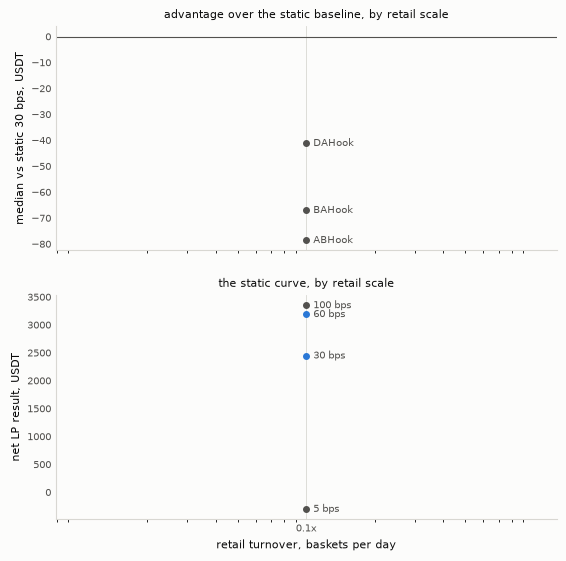

In [6]:
from IPython.display import Image, display

from experiments.figures import kappa_response

for suffix in ("pdf", "png"):
    kappa_response(tests, curve, FIGURES / f"kappa_response.{suffix}")
display(Image(filename=str(FIGURES / "kappa_response.png")))